In [24]:
import anndata as ad
import h5py

import numpy as np
import pandas as pd

import scipy
import scipy.sparse as sp
from scipy.stats import pearsonr, spearmanr, median_abs_deviation
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
from scipy.sparse import (
    csc_matrix,
    csr_matrix,
    coo_matrix,
    lil_matrix,
    save_npz,
    load_npz,
)

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

from tqdm import tqdm

from genome_tools.data.anndata import read_zarr_backed


## Prediction Analysis

### Functions

In [25]:
def pearson_or_nan(x, y):
    if len(x) < 2:
        return np.nan
    return pearsonr(x, y)[0]

def add_masks(df):
    df = df.copy()

    df["positive"] = (
        (df["FDR_sample"] < 0.1)
        & (np.abs(df["logit_es"]) < 6)
    )

    df["negative"] = df["FDR_sample"] > 0.5

    return df


In [26]:
def plot_hex_joint(
    df,
    actual_col,
    pred_col,
    xlim=(-2.5, 2.5),
    ylim=(-2.5, 2.5),
):

    plot_df = df[[actual_col, pred_col]].dropna()

    r = pearsonr(
        plot_df[actual_col],
        plot_df[pred_col]
    )[0]

    g = sns.jointplot(
        x=plot_df[actual_col],
        y=plot_df[pred_col],
        kind="hex",
        color="#2fc0fe",
        height=6,
        joint_kws=dict(
            gridsize=65,
            bins="log",
        ),
        marginal_kws=dict(bins=40),
    )

    ax = g.ax_joint

    ax.axhline(0, color="black", ls="--", lw=1)
    ax.axvline(0, color="black", ls="--", lw=1)

    ax.text(
        0.05,
        0.93,
        f"R={r:.2f}",
        transform=ax.transAxes,
        fontsize=18,
        ha="left",
        va="top",
    )

    ax.set_xlabel("Actual LFC")
    ax.set_ylabel("Predicted LFC")

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    plt.tight_layout()
    plt.show()

In [27]:
def compute_group_correlations(
    df,
    actual_col,
    pred_col,
    use_abs=False,
):

    results = []

    for group_id, g in df.groupby("group_id"):

        g = g[[actual_col, pred_col]].dropna()

        actual = (
            np.abs(g[actual_col])
            if use_abs
            else g[actual_col]
        )

        pred = (
            np.abs(g[pred_col])
            if use_abs
            else g[pred_col]
        )

        results.append(
            {
                "group_id": group_id,
                "pearson_r": pearson_or_nan(actual, pred),
                "n": len(g),
            }
        )

    return (
        pd.DataFrame(results)
        .sort_values("pearson_r", ascending=False)
    )
def compute_group_metrics(
    df,
    actual_col,
    pred_col="pred_group_es",
    use_abs=True,
):

    results = []
    if "positive" not in df.columns:
        df = add_masks(df)

    for group_id, g in df.groupby("group_id"):

        g = g[
            [
                actual_col,
                pred_col,
                "positive",
                "negative",
            ]
        ].dropna()

        if use_abs:
            actual = np.abs(g[actual_col])
            pred = np.abs(g[pred_col])
        else:
            actual = g[actual_col]
            pred = g[pred_col]

        pos = g["positive"]
        neg = g["negative"]

        results.append(
            {
                "group_id": group_id,
                "r_all": pearson_or_nan(actual, pred),
                "r_pos": pearson_or_nan(
                    actual[pos],
                    pred[pos],
                ),
                "r_neg": pearson_or_nan(
                    actual[neg],
                    pred[neg],
                ),
                "n_all": len(g),
                "n_pos": int(pos.sum()),
                "n_neg": int(neg.sum()),
            }
        )

    return pd.DataFrame(results)

In [28]:
def plot_group_scatter(
    df,
    actual_col,
    pred_col,
    use_abs=True,
    group_id=None,
    pdf_path=None,
):
    """
    Plot actual vs predicted values by group with marginal KDEs.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain:
            group_id
            positive
            negative
            actual_col
            pred_col

    actual_col : str
        Column containing actual values.

    pred_col : str
        Column containing predicted values.

    use_abs : bool, default=True
        If True, plot absolute values.
        If False, plot signed values.

    group_id : str or None
        If provided, only plot that group.
        Otherwise plot all groups.
    """

    df = df.copy()
    pdf = PdfPages(pdf_path) if pdf_path is not None else None
    if "positive" not in df.columns:
        df = add_masks(df)

    if group_id is not None:
        df = df[df["group_id"] == group_id]

    if use_abs:
        df["plot_actual"] = np.abs(df[actual_col])
        df["plot_pred"] = np.abs(df[pred_col])
    else:
        df["plot_actual"] = df[actual_col]
        df["plot_pred"] = df[pred_col]

    for current_group, g in df.groupby("group_id"):

        g = g.dropna(subset=["plot_actual", "plot_pred"])

        if len(g) < 2:
            continue

        pos = g[g["positive"]]
        neg = g[g["negative"]]
        other = g[(~g["positive"]) & (~g["negative"])]

        r_all = pearson_or_nan(
            g["plot_actual"],
            g["plot_pred"],
        )

        r_pos = pearson_or_nan(
            pos["plot_actual"],
            pos["plot_pred"],
        )

        r_neg = pearson_or_nan(
            neg["plot_actual"],
            neg["plot_pred"],
        )

        x = g["plot_actual"]
        y = g["plot_pred"]

        fig = plt.figure(figsize=(6, 6))

        gs = GridSpec(
            4,
            4,
            height_ratios=[1, 3, 3, 3],
            width_ratios=[3, 3, 3, 1],
            hspace=0.05,
            wspace=0.05,
        )

        ax_scatter = fig.add_subplot(gs[1:4, 0:3])
        ax_histx = fig.add_subplot(gs[0, 0:3], sharex=ax_scatter)
        ax_histy = fig.add_subplot(gs[1:4, 3], sharey=ax_scatter)

        # --------------------------------------------------
        # Scatter
        # --------------------------------------------------

        if len(other):
            ax_scatter.scatter(
                other["plot_actual"],
                other["plot_pred"],
                color="lightgray",
                s=8,
                alpha=0.35,
                label=f"Other (n={len(other)})",
                rasterized=True,
            )

        if len(neg):
            ax_scatter.scatter(
                neg["plot_actual"],
                neg["plot_pred"],
                color="orange",
                s=12,
                alpha=0.7,
                label=f"Negative (n={len(neg)})",
                rasterized=True,
            )

        if len(pos):
            ax_scatter.scatter(
                pos["plot_actual"],
                pos["plot_pred"],
                color="dodgerblue",
                s=16,
                alpha=0.85,
                label=f"Positive (n={len(pos)})",
                rasterized=True,
            )

        # --------------------------------------------------
        # Reference lines
        # --------------------------------------------------

        if use_abs:

            lim = max(
                g["plot_actual"].max(),
                g["plot_pred"].max(),
            )

            ax_scatter.plot(
                [0, lim],
                [0, lim],
                "--",
                color="red",
                linewidth=1,
            )

            ax_scatter.set_xlim(0, lim * 1.02)
            ax_scatter.set_ylim(0, lim * 1.02)

        else:

            lim = max(
                np.abs(g["plot_actual"]).max(),
                np.abs(g["plot_pred"]).max(),
            )

            ax_scatter.plot(
                [-lim, lim],
                [-lim, lim],
                "--",
                color="red",
                linewidth=1,
            )

            ax_scatter.axhline(
                0,
                color="black",
                linestyle="--",
                linewidth=0.8,
                alpha=0.5,
            )

            ax_scatter.axvline(
                0,
                color="black",
                linestyle="--",
                linewidth=0.8,
                alpha=0.5,
            )

            ax_scatter.set_xlim(-lim * 1.02, lim * 1.02)
            ax_scatter.set_ylim(-lim * 1.02, lim * 1.02)

        # --------------------------------------------------
        # Marginal KDEs
        # --------------------------------------------------

        if len(x) > 5:
            sns.kdeplot(
                x=x,
                ax=ax_histx,
                fill=True,
                alpha=0.3,
                color="black",
                linewidth=1,
            )
        else:
            ax_histx.hist(
                x,
                bins=10,
                color="gray",
                alpha=0.5,
            )

        if len(y) > 5:
            sns.kdeplot(
                y=y,
                ax=ax_histy,
                fill=True,
                alpha=0.3,
                color="black",
                linewidth=1,
            )
        else:
            ax_histy.hist(
                y,
                bins=10,
                orientation="horizontal",
                color="gray",
                alpha=0.5,
            )

        # --------------------------------------------------
        # Cleanup
        # --------------------------------------------------

        ax_histy.set_ylabel("")
        ax_histx.set_xlabel("")          # removes label text
        ax_histx.tick_params(labelbottom=False)  # removes tick labels

        # ax_histx.tick_params(labelbottom=False, left=True)
        ax_histx.set_ylabel("Density", fontsize=8)
        ax_histy.set_xlabel("Density", fontsize=8)
        ax_histy.tick_params(labelleft=False)

        for spine in ["top", "right", "left"]:
            ax_histx.spines[spine].set_visible(False)

        for spine in ["top", "right", "bottom"]:
            ax_histy.spines[spine].set_visible(False)

        # --------------------------------------------------
        # Labels
        # --------------------------------------------------

        if use_abs:
            ax_scatter.set_xlabel("Absolute value aggregated actual group logit ES")
            ax_scatter.set_ylabel("Absolute value aggregated predicted group logit ES")
        else:
            ax_scatter.set_xlabel("Aggregated actual group logit ES")
            ax_scatter.set_ylabel("Aggregated predicted group logit ES")

        ax_scatter.legend(
            frameon=False,
            fontsize=8,
        )

        fig.suptitle(
            f"{current_group} | "
            f"All r={r_all:.3f} | "
            f"Pos r={r_pos:.3f} | "
            f"Neg r={r_neg:.3f}",
            fontsize=11,
            y=0.98,
        )

        plt.tight_layout()

        if pdf is not None:
            pdf.savefig(fig, dpi=150)
        else:
            plt.show()
        
        plt.close(fig)
        

### Evaluate

In [16]:
### nexflow aggregate
agg_df = pd.read_parquet('/net/seq/data2/projects/mbrannon/output/all_groups_with_predictions_wmeta_agg.parquet')


In [68]:
### from aggregated bed
agg_df = pd.read_parquet('/net/seq/data2/projects/mbrannon/group_row_predictions/all_groups_with_predictions.parquet')

#### Adjust aggregated data

In [36]:
### re aggregate
nonag_pred = pd.read_parquet('/net/seq/data2/projects/mbrannon/nonag_recovered/group_row_predictions/all_groups_with_predictions_6_17.parquet')
nonag_pred.head()

,BAD,FDR_sample,alt,chrom,es,indiv_id,inverse_mse,logit_es,pos,ref,ref_counts,sample_id,total_counts,pred,group_id,pred_group_es
0,1.0,0.864155,b'T',b'chr1',0.512195,b'DNASE_INDIV_0160',15.763402,0.069306,41893353,b'C',21,b'AG80013',41,0.009186,ALL,0.005272
1,1.0,0.864155,b'T',b'chr19',0.496403,b'DNASE_INDIV_0160',29.024546,-0.020439,41860325,b'C',69,b'AG80013',139,-0.025167,ALL,-0.023700
2,1.5,NaN,b'T',b'chr8',0.481744,b'DNASE_INDIV_0160',7.801364,-0.103777,144290016,b'C',6,b'AG80012',13,-0.019654,ALL,-0.019546
3,1.0,0.953221,b'A',b'chr4',0.531250,b'DNASE_INDIV_0160',13.926212,0.177787,102828287,b'G',17,b'AG80015',32,0.128029,ALL,0.132357
4,1.5,0.832576,b'C',b'chr16',0.546207,b'DNASE_INDIV_0160',8.122578,0.263274,1984660,b'T',9,b'AG80012',15,-0.056394,ALL,-0.059012


In [39]:
nonag_pred["chrom"] = nonag_pred["chrom"].str.decode("utf-8")
nonag_pred["alt"] = nonag_pred["alt"].str.decode("utf-8")
nonag_pred["sample_id"] = nonag_pred["sample_id"].str.decode("utf-8")
nonag_pred["ref"] = nonag_pred["ref"].str.decode("utf-8")
nonag_pred['indiv_id']=nonag_pred["indiv_id"].str.decode("utf-8")
nonag_pred=nonag_pred.rename(columns={'pos':'end','chrom':'#chr'})

In [37]:
#get columns from orgininal bed file
meta = pd.read_parquet('/net/seq/data2/projects/nasi4/ENCODE4/dnase+atac-cavs.v1/output/non_aggregated.extended_annotation.parquet')

In [38]:
meta.columns

Index(['#chr', 'start', 'end', 'ID', 'ref', 'alt', 'ref_counts', 'alt_counts',
       'sample_id', 'AAF', 'RAF', 'FMR', '#chr.1', 'start.1', 'end.1', 'BAD',
       'SNP_count', 'SNP_ID_count', 'sum_cover', 'Q1.00', 'Q1.50', 'Q2.00',
       'Q2.50', 'Q3.00', 'Q4.00', 'Q5.00', 'Q6.00', 'coverage', 'w', 'es',
       'logit_es', 'pval_ref', 'pval_alt', 'min_pval', 'FDR_sample',
       'hotspots', 'footprints', 'peaks', 'inverse_mse', 'group_id'],
      dtype='object')

In [ ]:
merged = nonag_pred.merge(
    meta,
    on=["#chr", "end", "sample_id", "ref", "alt"],
    how="left",
)

In [ ]:
merged_wmeta

In [ ]:
merged = merged_wmeta

In [ ]:
#make agg
import numpy as np
import pandas as pd

def aggregate_effect_size(es, weights):
    return np.average(es, weights=weights)

agg_df = (
    merged
    .groupby(['#chr', "start", "ref", "alt", "group_id"], as_index=False)
    .apply(lambda df: pd.Series({
        "new_group_es": aggregate_effect_size(df["es"], df["inverse_mse"]),
        "pred_group_es": aggregate_effect_size(df["pred"], df["inverse_mse"]),
        "new_logit_group_es": aggregate_effect_size(df["logit_es"], df["inverse_mse"]),
        "min_FDR_sample": df["FDR_sample"].min(),
        "median_FDR_sample": df["FDR_sample"].median(),
        "n_samples": df["sample_id"].nunique(),
        "sum_weights": df["inverse_mse"].sum(),
    }))
    .reset_index(drop=True)
)

#### continue analysis

In [17]:
agg_df = agg_df.rename(
    columns={
        "agg_pred_logit_es": "pred_group_es",
        "agg_logit_group_es": "logit_es",
        "median_FDR_sample": "FDR_sample",
    }
)

agg_df["logit_es_scaled"] = (
    agg_df["logit_es"] * np.log(2)
)

print(agg_df.shape)
agg_df.head()

(23922593, 13)


,chrom,pos,ref,alt,group_id,agg_group_es,pred_group_es,logit_es,min_FDR_sample,FDR_sample,n_samples,sum_weights,logit_es_scaled
0,b'chr1',944858,b'A',b'G',Bladder,0.562058,-0.038926,0.354383,NaN,NaN,1.0,7.145565,0.245639
1,b'chr1',976215,b'A',b'G',Bladder,0.774592,0.917680,1.746222,NaN,NaN,1.0,7.609493,1.210389
2,b'chr1',976536,b'C',b'T',Bladder,0.415929,-0.107506,-0.482126,NaN,NaN,1.0,7.392234,-0.334184
3,b'chr1',995982,b'G',b'A',Bladder,0.584071,-0.391230,0.482126,NaN,NaN,1.0,7.392234,0.334184
4,b'chr1',1000112,b'G',b'T',Bladder,0.824429,0.292239,2.182138,1.0,1.0,1.0,8.257590,1.512543


In [19]:
# agg_df["chrom"] = agg_df["chrom"].str.decode("utf-8")

# subset = agg_df[agg_df["chrom"].isin(["chr9", "chr22"])]

# agg_df = subset

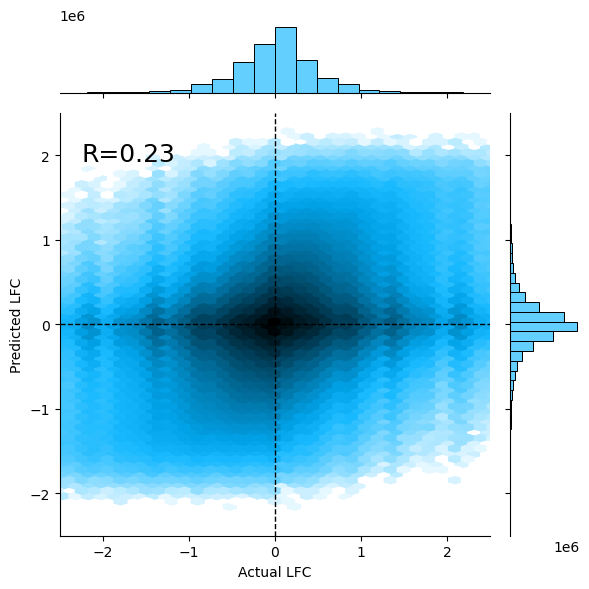

In [20]:
plot_hex_joint(
    agg_df,
    actual_col="logit_es_scaled",
    pred_col="pred_group_es",
)

In [32]:
results_df = compute_group_metrics(
    agg_df,
    actual_col="logit_es_scaled",
    use_abs=False,
)

/tmp/slurm.16743749/ipykernel_2187756/903150465.py:270: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


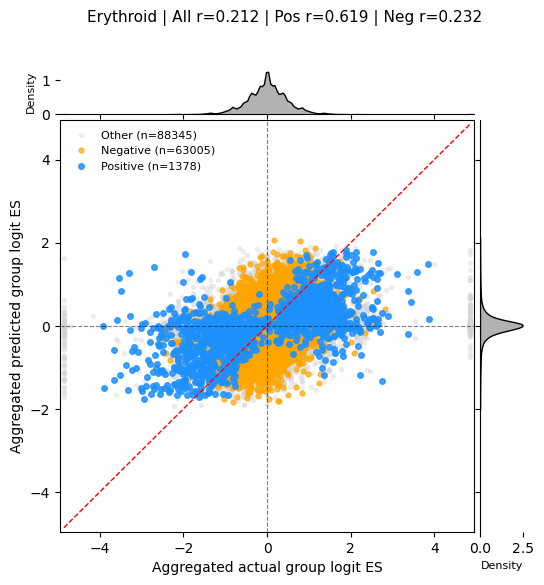

In [22]:
plot_group_scatter(
    agg_df,
    actual_col="logit_es_scaled",
    pred_col="pred_group_es",
    use_abs=False,
    group_id="Erythroid",
)

/tmp/slurm.16743749/ipykernel_2187756/903150465.py:270: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


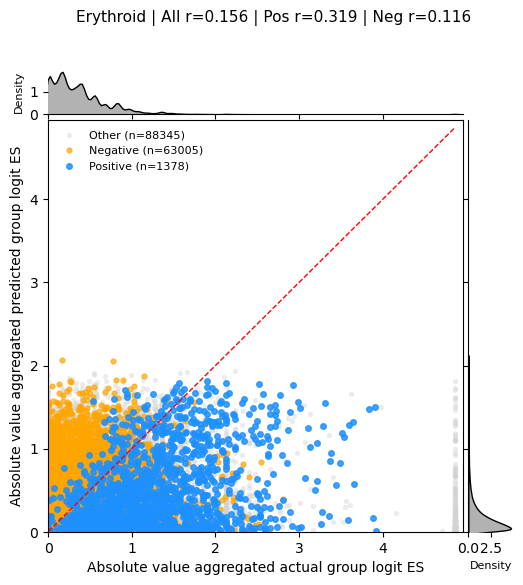

In [23]:
plot_group_scatter(
    agg_df,
    actual_col="logit_es_scaled",
    pred_col="pred_group_es",
    use_abs=True,
    group_id="Erythroid",
)

In [ ]:
# if want to save all groups to pdf run like this
# plot_group_scatter(
#     plot_df,
#     actual_col="logit_es_scaled",
#     pred_col="pred_group_es",
#     use_abs=True,
#     pdf_path="pearson_pos_filter_abs_hist.pdf",
# )

In [33]:
bins = [0, 100, 500, 1000, 2000, np.inf]
labels = [
    "<100",
    "100–500",
    "500–1000",
    "1000–2000",
    "2000+",
]

results_df["n_pos_bin"] = pd.cut(
    results_df["n_pos"],
    bins=bins,
    labels=labels,
    include_lowest=True,
)

color_map = {
    "<100": "lightgray",
    "100–500": "skyblue",
    "500–1000": "dodgerblue",
    "1000–2000": "blue",
    "2000+": "navy",
}

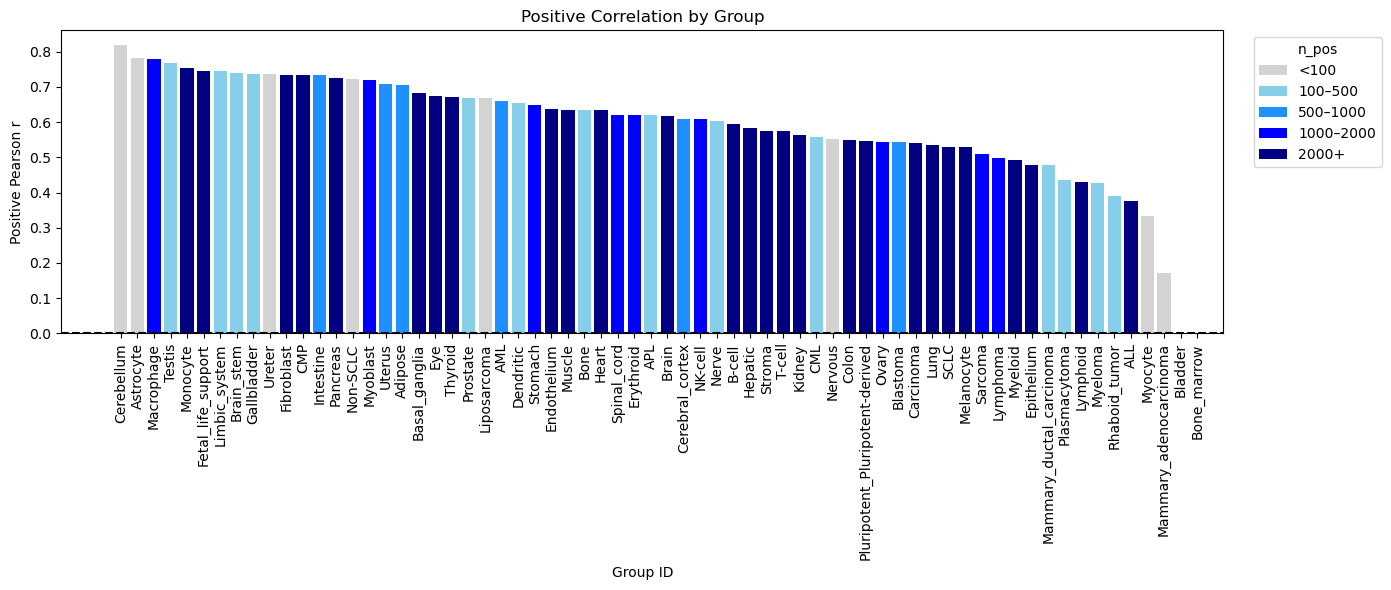

In [35]:
from matplotlib.patches import Patch
results_df = results_df.sort_values(
    "r_pos",
    ascending=False,
)

plt.figure(figsize=(14, 6))

plt.bar(
    results_df["group_id"],
    results_df["r_pos"],
    color=results_df["n_pos_bin"].map(color_map),
)

plt.axhline(
    0,
    color="black",
    ls="--",
)

plt.xticks(rotation=90)

plt.xlabel("Group ID")
plt.ylabel("Positive Pearson r")
plt.title("Positive Correlation by Group")

legend_elements = [
    Patch(
        facecolor=color_map[label],
        label=label,
    )
    for label in labels
]

plt.legend(
    handles=legend_elements,
    title="n_pos",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

## Check if agg before matches after

In [ ]:
### nexflow aggregate
after = pd.read_parquet('/net/seq/data2/projects/mbrannon/output/all_groups_with_predictions_wmeta_agg.parquet')
### from aggregated bed
before = pd.read_parquet('/net/seq/data2/projects/mbrannon/group_row_predictions/all_groups_with_predictions.parquet')

In [36]:
group = "Erythroid"

merge_cols = ["chrom", "pos", "ref", "alt", "group_id"]

comparison = (
    before.query("group_id == @group")
    .merge(
        after.query("group_id == @group"),
        on=merge_cols,
        suffixes=("_before", "_after")
    )
)

comparison["delta_logit_es"] = (
    comparison["logit_es_after"]
    - comparison["logit_es_before"]
)

comparison.head()

,chrom,pos,ref,alt,group_id,agg_group_es,pred_group_es_before,logit_es_before,min_FDR_sample,FDR_sample_before,...,logit_es_after,ref_counts,sample_id,total_counts,pred,pred_group_es_after,logit_es_scaled_after,positive_after,negative_after,delta_logit_es
0,b'chr1',832323,b'G',b'A',Erythroid,0.685678,-1.039423,1.296220,0.165608,0.165608,...,1.106211,NaN,b'Erythroid',15.500000,-0.797230,-0.797230,0.766767,False,False,-0.190009
1,b'chr1',869909,b'C',b'G',Erythroid,0.490305,-0.001757,-0.055090,0.977788,1.000000,...,-0.020322,NaN,b'Erythroid',41.568421,0.005471,0.005471,-0.014086,False,True,0.034767
2,b'chr1',870176,b'T',b'A',Erythroid,0.584071,0.109027,0.482126,NaN,NaN,...,1.164207,NaN,b'Erythroid',13.750000,-0.119046,-0.119046,0.806967,False,False,0.682081
3,b'chr1',903723,b'A',b'G',Erythroid,0.400000,-0.073775,-0.575720,1.000000,1.000000,...,-0.480230,NaN,b'Erythroid',12.500000,0.006068,0.006068,-0.332870,False,True,0.095490
4,b'chr1',904947,b'G',b'A',Erythroid,0.550000,0.008319,0.285023,1.000000,1.000000,...,0.285023,NaN,b'Erythroid',20.000000,0.029995,0.029995,0.197563,False,True,0.000000


In [38]:
same = (
    comparison["logit_es_before"]
    == comparison["logit_es_after"]
).sum()

different = (
    comparison["logit_es_before"]
    != comparison["logit_es_after"]
).sum()

print(f"Same: {same:,}")
print(f"Different: {different:,}")
print(f"Percent same: {100 * same / len(comparison):.2f}%")

Same: 16,174
Different: 57,571
Percent same: 21.93%


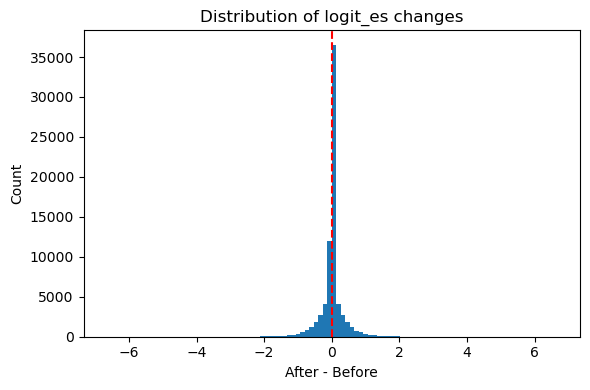

In [39]:
plt.figure(figsize=(6, 4))

plt.hist(
    comparison["delta_logit_es"],
    bins=100,
)

plt.axvline(
    0,
    color="red",
    linestyle="--",
)

plt.xlabel("After - Before")
plt.ylabel("Count")
plt.title("Distribution of logit_es changes")

plt.tight_layout()
plt.show()

In [42]:
comparison["abs_delta"] = np.abs(comparison["delta_logit_es"])

top10 = (
    comparison
    .sort_values("abs_delta", ascending=False)
    .head(50)
)

top10 = top10[(top10["agg_group_es"] != 0) & (top10["agg_group_es"] != 1)]

In [48]:
results_df = compute_group_metrics(
    plot_df,
    actual_col="logit_es_scaled",
    use_abs=False,
)

results_df = (
    results_df
    .sort_values("r_pos", ascending=False)
    .reset_index(drop=True)
)

results_df.head()

,group_id,r_all,r_pos,r_neg,n_all,n_pos,n_neg
0,Cerebellum,0.343346,0.819263,0.366006,6863,12,4386
1,Astrocyte,0.368933,0.782733,0.410387,93007,28,64268
2,Macrophage,0.478005,0.778776,0.499710,127647,1252,78280
3,Testis,0.397228,0.766539,0.284583,30576,388,15510
4,Monocyte,0.385830,0.753842,0.388873,122168,2715,56355


## From figure 2 code ---- NOT TESTED WITH UPDATE YET

In [ ]:
## name components
import logging
import warnings

from typing import Sequence, Union
from matplotlib import gridspec
from matplotlib import transforms
import matplotlib.pyplot as plt
from genome_tools import GenomicInterval

from typing import Sequence
from genome_tools.plotting import signal_plot


class LoggerMixin:
    def __init__(self, logger_level: int = logging.INFO):
        self.logger = logging.getLogger(self.__class__.__name__)
        self.logger.setLevel(logger_level)



In [ ]:
class PlotComponent(LoggerMixin):
    def __init__(
        self,
        width: float = 1.0,
        margins: Union[float, Sequence[float]] = 0.1,
        names_to_colors: dict = None,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.width = width
        self.names_to_colors = names_to_colors

        if isinstance(margins, Sequence) and not isinstance(margins, str):
            if len(margins) != 2:
                raise ValueError("margins must be length 2")
            self.margin_left, self.margin_right = margins
        else:
            self.margin_left = self.margin_right = margins

    def plot(self, data, gs, fig, **kwargs):
        raise NotImplementedError

In [ ]:
short_to_full_group_name = {
    'ALL': 'Adult tissues (Mixed)',
    'AML': 'Myeloid (CMP)',
    'APL': 'Myeloid (Erythroid)',
    'Adipose': 'Adult tissues (Heart/Muscle/Stromal)',
    'Adrenal': 'Endocrine (Adrenal)',
    'Astrocyte': 'Nervous (Fetal CNS/Eye)',
    'B-cell': 'Lymphoid (B-cells)',
    'Bladder': 'Epithelial',
    'Brain stem': 'Nervous (Cortex/Limbic/Spinal chord)',
    'Bone': 'Adult tissues (Mixed)',
    'Bone marrow': 'Myeloid (CMP)',
    'CMP': 'Myeloid (CMP)',
    'CML': 'Myeloid (Erythroid/CMP)',
    'Carcinoma': 'Epithelial',
    'Cerebellum': 'Nervous (Cerebellum)',
    'Fetal life support': 'Fetal life support (Trophoblasts)',
    'Cerebral cortex': 'Nervous (Cortex/Limbic/Spinal chord)',
    'Colon': 'Gastrointestinal (Adult Intestine)',
    'Dendritic': 'Myeloid (Macrophage) A',
    'Endothelium': 'Endothelial',
    'Epithelium': 'Epithelial',
    'Erythroid': 'Myeloid (Erythroid)',
    'Eye': 'Nervous (Fetal CNS/Eye)',
    'Hepatic': 'Gastrointestinal/Endocrine (Pancreas/Liver/Stomach)',
    'Fibroblast': 'Stromal (Skin fibroblasts)',
    'Gallbladder': 'Gastrointestinal (Adult Intestine)',
    'Heart': 'Adult tissues (Heart/Muscle/Stromal)',
    'Limbic system': 'Nervous (Cortex/Limbic/Spinal chord)',
    'Intestine': 'Gastrointestinal (Adult Intestine)',
    'Lung': 'Respiratory (Fetal)',
    'Liposarcoma': 'Adult tissues (Mixed)',
    'Pancreas': 'Gastrointestinal/Endocrine (Pancreas/Liver/Stomach)',
    'Plasmacytoma': 'Myeloid (Erythroid/CMP)',
    'Lymphoma': 'Lymphoid (B-lymphoblasts)',
    'Macrophage': 'Myeloid (Macrophage) B',
    'Mammary adenocarcinoma': 'Epithelial',
    'Mammary ductal carcinoma': 'Epithelial',
    'Melanocyte': 'Epithelial',
    'Monocyte': 'Myeloid (Monocyte)',
    'Muscle': 'Adult tissues (Heart/Muscle/Stromal)',
    'Myeloma': 'Myeloid (Erythroid/CMP)',
    'Myoblast': 'Skeletal muscle (Fetal)',
    'Myocyte': 'Skeletal muscle (Fetal)',
    'NK-cell': 'Lymphoid (NK-cells)',
    'Nerve': 'Nervous (Cortex/Limbic/Spinal chord)',
    'Non-SCLC': 'Lung',
    'Ovary': 'Ovary/Uterus',
    'Stroma': 'Stromal/Epithelial',
    'T-cell': 'Lymphoid (Activated T-cells)',
    'Pluripotent/Pluripotent-derived': 'Pluripotent/Pluripotent-derived',
    'Prostate': 'Epithelial',
    'Rhaboid tumor': 'Adult tissues (Mixed)',
    'SCLC': 'Lung',
    'Sarcoma': 'Adult tissues (Mixed)',
    'Spinal cord': 'Nervous (Cortex/Limbic/Spinal chord)',
    'Uterus': 'Ovary/Uterus',
    'Ureter': 'Renal (Fetal)',
    'Testis': 'Endocrine (Adrenal)',
    'Thyroid': 'Endocrine (Thyroid)',
    'Basal ganglia': 'Nervous (Basal ganglia)',
    'Kidney': 'Epithelial (Kidney)',
    'Stomach': 'Gastrointestinal (Stomach)'
}

In [ ]:
class LoggerMixin:
    def __init__(self, logger_level: int = logging.INFO):
        self.logger = logging.getLogger(self.__class__.__name__)
        self.logger.setLevel(logger_level)


class PlotComponent(LoggerMixin):
    def __init__(self,
                 width: float = 1.0,
                 margins: Union[float, Sequence[float]] = 0.1,
                 names_to_colors: dict = None,
                 **kwargs):
        super().__init__(**kwargs)

        self.width = width
        self.names_to_colors = names_to_colors

        if isinstance(margins, Sequence) and not isinstance(margins, str):
            if len(margins) == 2:
                self.margin_left, self.margin_right = margins
            else:
                raise ValueError("If margins is a sequence, it must have exactly two elements.")
        else:
            self.margin_left, self.margin_right = margins, margins

    def plot(self, data, gs, fig, **kwargs):
        raise NotImplementedError


class VariantDataPreprocessor(LoggerMixin):
    def __init__(self,
                 tested_variants: pd.DataFrame,
                 anova_results: pd.DataFrame,
                 metadata: pd.DataFrame,
                 **kwargs):
        super().__init__(**kwargs)

        self.tested_variants = tested_variants
        self.anova_results = anova_results
        self.metadata = metadata
    
    def variant_query(self, variant_id: str):
        tested_df = self.tested_variants.query(f'variant_id == "{variant_id}"')
        anova_df = self.anova_results.query(f'variant_id == "{variant_id}"')
        if tested_df.empty or anova_df.empty:
            self.logger.error(f'Variant {variant_id} was not found in the variants data.')
        return tested_df, anova_df
    
    def filter_dfs(self, tested_df, anova_df, groups, coverage_tr):
        if groups is not None:
            anova_df = anova_df[anova_df['group_name'].isin(groups)]
            tested_df = tested_df[tested_df['group_name'].isin(groups)]

        if coverage_tr > 0:
            tested_df = tested_df.query(f'(ref_counts + alt_counts) >= {coverage_tr}')
            anova_df = anova_df[anova_df['group_name'].isin(tested_df['group_name'])]


        if tested_df.empty or anova_df.empty:
            self.logger.error(f'No data left after filtering with groups {groups} and coverage threshold {coverage_tr}')
        return tested_df, anova_df

    def get_variant_data(self,
                         variant_id: str,
                         components: Sequence[PlotComponent],
                         sort_eval: str = 'group_es',
                         groups: list = None,
                         coverage_tr: int = 0):

        tested_df, anova_df = self.variant_query(variant_id)

        tested_df, anova_df = self.filter_dfs(tested_df, anova_df, groups, coverage_tr)
        anova_df = anova_df.iloc[anova_df.eval(sort_eval).argsort()]

        component_data = []
        for component in components:
            if isinstance(component, DensityPlotComponent):
                dens, interval = self.get_density(tested_df)
                data = anova_df, dens, interval
            elif isinstance(component, ImbalancePlotComponent):
                data = tested_df, anova_df
            elif isinstance(component, PredictionPlotComponent):
                data = anova_df
            elif isinstance(component, ContributionPlotComponent):
                X, all_scores = self.get_shap_scores(anova_df)
                data = anova_df, X, all_scores
            else:
                self.logger.error(f'Unsupported component type: {type(component)}')
                raise

            component_data.append(data)

        return components, component_data, len(anova_df)

    def get_density(self, tested_df):
        dens = {}
        for group_id, df in self.metadata.merge(tested_df, left_on="ag_id", right_on="sample_id").groupby("group_name"):
            has_bam = df['cram_file'].notna()
            if has_bam.sum() == 0:
                dens[group_id] = np.zeros(df["end"].iloc[0] - df["start"].iloc[0], dtype=np.float_)
                continue
            df = df[has_bam]
            #normed_dens_files = (df['cram_file'].apply(lambda x: os.path.dirname(x)) + "/normalized.density.bw").tolist()
            normed_dens_files = (df["normalized_density_bw"].dropna().tolist())
            chrom, start, end = df["#chr"].iloc[0], df["start"].iloc[0], df["end"].iloc[0]
            interval = genomic_interval(chrom, start, end).widen(2000)
            
            d = []
            for ndf in normed_dens_files:
                bw_extractor = bigwig_extractor(ndf)
                d.append(bw_extractor[interval])
            
            dens[group_id] = np.average(np.array(d), axis=0, weights=df['inverse_mse'])

        return dens, interval
    
    def get_shap_scores(self, anova_df):
        X = []
        all_scores = []
        for CL, h5_num_index in anova_df[['group_id', 'h5_contr_num_index']].values:
            if pd.isna(h5_num_index):
                warnings.warn(f'No contribution score for {CL}')
                X.append(None)
                all_scores.append(None)
                continue
            with h5py.File(f'/net/seq/data2/projects/jvierstra/ENCODE4-variant-nn/pipeline/dnase.variants/output/{CL}_cluster/shap.h5') as f:
                dataset = {
                    'seq0': f['inputs']['seq0'][h5_num_index, :],
                    'seq1': f['inputs']['seq1'][h5_num_index, :],
                    'features': f['inputs']['features'][h5_num_index, :],
                }
                X.append({k: np.expand_dims(v, axis=0) for k, v in dataset.items()})
                all_scores.append([f['contribs']['effect']['seq0'][h5_num_index], f['contribs']['effect']['seq1'][h5_num_index]])
        return X, all_scores
    

# --------------------------------------- Plotting ---------------------------------------
    
class ImbalancePlotComponent(PlotComponent):
    def __init__(self, use_stripplot=False, **kwargs):
        super().__init__(**kwargs)
        self.use_stripplot = use_stripplot  # optional toggle

    def plot(self, data, gs, fig):
        tested_df, anova_df = data

        ref_allele = anova_df['ref'].values[0]
        alt_allele = anova_df['alt'].values[0]
        rsid = anova_df['ID'].values[0]

        ax = fig.add_subplot(gs)

        # ---------------------------------------
        # OPTIONAL: raw points (actual data)
        # ---------------------------------------
        if self.use_stripplot:
            sns.stripplot(
                data=tested_df,
                y='group_name',
                x='logit_es',
                order=anova_df['group_name'],
                ax=ax,
                s=5,
                zorder=-1,
                orient='h',
                palette=self.names_to_colors,
                alpha=0.3
            )

        # ---------------------------------------
        # Predicted values
        # ---------------------------------------
        x = anova_df['pred_group_es']
        xerr = anova_df.get('pred_group_es_std', None)

        # Error bars
        if xerr is not None:
            ax.errorbar(
                x=x,
                y=anova_df['group_name'],
                xerr=xerr,
                fmt='.',
                capsize=4,
                capthick=1.0,
                c='k',
                lw=1.0
            )

        # Points
        ax.scatter(
            y=anova_df['group_name'],
            x=x,
            lw=3,
            ec=anova_df['group_name'].map(self.names_to_colors).values,
            color='k',
            s=12
        )

        # ---------------------------------------
        # Formatting
        # ---------------------------------------
        ax.set_yticklabels([
            x.get_text().replace(' (', '\n(').replace('/', '/\n')
            for x in ax.get_yticklabels()
        ])

        trans = transforms.blended_transform_factory(ax.transAxes, ax.transAxes)

        ax.annotate(
            alt_allele,
            xy=(0.1, 1.05),
            xycoords=trans,
            fontname="IBM Plex Mono",
            fontweight="bold",
            fontsize=7,
            bbox=dict(boxstyle="Circle", ec='none',
                      fc=cm.map_vocab_color(alt_allele, 'dna')[0])
        )

        ax.annotate(
            ref_allele,
            xy=(0.9, 1.05),
            xycoords=trans,
            fontname="IBM Plex Mono",
            fontweight="bold",
            fontsize=7,
            bbox=dict(boxstyle="Circle", ec='none',
                      fc=cm.map_vocab_color(ref_allele, 'dna')[0])
        )

        # Horizontal separators
        for i in range(len(anova_df['group_name']) - 1):
            ax.axhline(i + 0.5, ls='--', color='k', lw=0.5)

        # ---------------------------------------
        # Axis limits (robust to missing std)
        # ---------------------------------------
        if xerr is not None:
            xmin = (x - xerr).min()
            xmax = (x + xerr).max()
        else:
            xmin = x.min()
            xmax = x.max()

        val = max(abs(xmin), abs(xmax)) * 1.1

        # ---------------------------------------
        # Asterisks (still based on FDR)
        # ---------------------------------------
        for i, (_, row) in enumerate(anova_df.iterrows()):
            if row['fdr_group'] <= 0.1:
                if row['pred_group_es'] > 0:
                    star_x = row['pred_group_es'] + (row.get('pred_group_es_std', 0) or 0) + val * 0.1
                else:
                    star_x = row['pred_group_es'] - (row.get('pred_group_es_std', 0) or 0) - val * 0.1

                ax.text(
                    s='*',
                    x=star_x,
                    y=i + 0.15,
                    fontsize=20,
                    color='red',
                    ha='center',
                    va='center'
                )

        # ---------------------------------------
        # Final styling
        # ---------------------------------------
        ax.set_ylim(len(anova_df['group_name']) - 1 + 0.5, -0.5)

        ax.tick_params('x', length=3, width=0.75)
        ax.tick_params('y', length=0)

        ax.spines['left'].set_linewidth(0.75)
        ax.spines['bottom'].set_linewidth(0.75)

        ax.axvline(0, ls='--', color='k', lw=0.5)
        ax.axvspan(-0.5, 0.5, color='grey', alpha=0.1, lw=0)

        ax.set_xlabel("Predicted variant effect size (log2 ref/alt)")
        ax.set_ylabel("")
        ax.set_xlim(-val * 1.3, val * 1.3)
        ax.set_title(rsid)

        return ax
# class ImbalancePlotComponent(PlotComponent):
#     def __init__(self, **kwargs):
#         super().__init__(**kwargs)

#     def plot(self, data, gs, fig):
#         tested_df, anova_df = data
#         ref_allele, alt_allele, rsid = anova_df['ref'].values[0], anova_df['alt'].values[0], anova_df['ID'].values[0]
#         ax = fig.add_subplot(gs)
#         sns.stripplot(data=tested_df, y='group_name', x='logit_es', order=anova_df['group_name'], ax=ax, s=5, zorder=-1, orient='h',
#                  palette=self.names_to_colors, alpha=0.3)
        
#         ax.errorbar(x=anova_df['logit_group_es'], y=anova_df['group_name'], xerr=anova_df['logit_group_es_std'], fmt='.', capsize=4, capthick=1.0, c='k', lw=1.0)
#         ax.scatter(y=anova_df['group_name'], x=anova_df['logit_group_es'], lw=3, ec=anova_df['group_name'].map(self.names_to_colors).values, color='k', s=12)
#         ax.set_yticklabels([x.get_text().replace(' (', '\n(').replace('/', '/\n') for x in ax.get_yticklabels()])

#         trans = transforms.blended_transform_factory(ax.transAxes, ax.transAxes)
        
#         ax.annotate(alt_allele, xy=(0.1, 1.05), xycoords=trans, fontname="IBM Plex Mono", fontweight="bold", fontsize=7, bbox=dict(boxstyle="Circle", ec='none', fc=cm.map_vocab_color(alt_allele, 'dna')[0]))
#         ax.annotate(ref_allele, xy=(0.9, 1.05), xycoords=trans, fontname="IBM Plex Mono", fontweight="bold", fontsize=7, bbox=dict(boxstyle="Circle", ec='none', fc=cm.map_vocab_color(ref_allele, 'dna')[0]))

#         for i in range(len(anova_df['group_name']) - 1):
#             ax.axhline(i + 0.5, ls='--', color='k', lw=0.5)


#         #---------------------------------------
#         # asterisks
#         minx, maxx = (min(-0.1, tested_df['logit_es'].min(), (anova_df['logit_group_es'] - anova_df['logit_group_es_std']).min()), max(0.1, tested_df['logit_es'].max(), (anova_df['logit_group_es'] + anova_df['logit_group_es_std']).max()))
#         val = max(np.abs(x) for x in [minx, maxx]) * 1.1
#         # val = min(5.0, val)

#         for i, (_ , row) in enumerate(anova_df.iterrows()):
#             if row['fdr_group'] <= 0.1: ## Asterisk criterion  <--------
#                 if row['logit_group_es'] > 0:
#                     asterisk_x = (row['logit_group_es'] + row['logit_group_es_std']) + val * 0.1
#                 else:
#                     asterisk_x = (row['logit_group_es'] - row['logit_group_es_std']) - val * 0.1

#                 ax.text(s='*', x=asterisk_x, y=i+0.15, fontdict={'size': 20, 'color': 'red'}, ha='center', va='center')

#         ax.set_ylim(len(anova_df['group_name']) - 1 + 0.5, -0.5)

#         ax.set_yticks([x - 0.125 for x in ax.get_yticks()], )
#         ax.tick_params('x', length=3, width=0.75, which='major')
#         ax.tick_params('y', length=0, width=0, which='major')

#         ax.spines['left'].set_linewidth(0.75)
#         ax.spines['bottom'].set_linewidth(0.75)
        
#         ax.axvline(0, ls='--', color='k', lw=0.5)
#         ax.axvspan(-0.5, 0.5, color='grey', alpha=0.1, lw=0)
        
#         ax.set_xlabel("Variant effect size (log2 ref/alt)")
#         ax.set_ylabel("")

#         ax.set_xlim(-val*1.3, val*1.3)
#         ax.set_title(rsid)

#         return ax


class DensityPlotComponent(PlotComponent):
    def __init__(self, common_norm=True, clip_max=None, clip_min=0, common_norm_quantile=1.0, **kwargs):
        super().__init__(**kwargs)
        self.common_norm = common_norm # wether to set a common y scale for all density plots
        self.common_norm_quantile = common_norm_quantile # quantile of max y values across rows to use as ylim
        self.clip_max = clip_max # hard threshold that ylim can not exceed
        self.clip_min = clip_min # hard threshold that ylim can not be lower than
        

    def plot(self, data, gs, fig):
        anova_df, dens, interval = data
        ref_allele = anova_df['ref'].values[0]
        alt_allele = anova_df['alt'].values[0]
        gs_subplot = gridspec.GridSpecFromSubplotSpec(len(anova_df), 1, gs, hspace=0)
        axes = []

        for i, group_name in enumerate(anova_df['group_name']):
            ax = fig.add_subplot(gs_subplot[i, :])
            signal_plot(interval, dens[group_name], color=self.names_to_colors[group_name], ax=ax)
            
            if i == len(anova_df)-1:
                ax.xaxis.set_visible(True)
                ax.set_xlabel(f"{anova_df['#chr'].values[0]}")
                ax.tick_params('x', length=3, width=0.7, which='major')
            else:
                ax.xaxis.set_visible(False)

            max_dens_value = np.nanmax(dens[group_name])
        
            if i == 0:
                ax.annotate(xy=((interval.end+interval.start)//2, max_dens_value), ha='center', text=f"{ref_allele}/{alt_allele}", xytext=(0, 25), textcoords="offset points", arrowprops=dict(arrowstyle="->"))

            ax.set_yticks([])
            ax.spines['left'].set_linewidth(0.75)
            ax.spines['bottom'].set_linewidth(0.75)
            pos = ax.get_position()
            ax.set_ylim(0, np.clip(max_dens_value, self.clip_min, self.clip_max))
            ax.set_position([pos.x0, pos.y0, pos.width, pos.height * 0.8])
            axes.append(ax)

        if self.common_norm:
            top = np.nanquantile([np.nanmax(d) for d in dens.values()], self.common_norm_quantile)
            top = np.clip(top, self.clip_min, self.clip_max)
            for ax in axes:
                ax.set_ylim(0, top)
        
        common_ax = fig.add_subplot(gs)
        common_ax.axvline(0.5, ls='--', color='k', lw=0.5)
        common_ax.axis('off')
        common_ax.annotate(xy=(-0.1, 0.5), ha='center', va='center', rotation=90, text='DNase I density', annotation_clip=False)
        return axes, common_ax


class PredictionPlotComponent(PlotComponent):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def plot(self, data, gs, fig):
        anova_df = data
        alt_allele = anova_df['alt'].values[0]
        ref_allele = anova_df['ref'].values[0]
        gs_subplot = gridspec.GridSpecFromSubplotSpec(len(anova_df), 1, subplot_spec=gs)
        axes = []
        for i, g in enumerate(anova_df['group_name']):
            group_ax = fig.add_subplot(gs_subplot[i,:])
            axes.append(group_ax)
            group_ax.bar(x=[0, 1, 2], height=anova_df.query(f'group_name == "{g}"')[['pred_alt', 'pred_0', 'pred_ref']].values[0, :],
                color=[
                    cm.map_vocab_color(alt_allele, 'dna')[0],
                    mcolors.to_rgba('grey'),
                    cm.map_vocab_color(ref_allele, 'dna')[0],
                ])

            group_ax.set_ylim(0, 1)
            group_ax.spines['left'].set_linewidth(0.75)
            group_ax.spines['bottom'].set_linewidth(0.75)
            group_ax.tick_params('x', length=3, width=0.75, which='major')
            group_ax.tick_params('y', length=3, width=0.75, which='major')
            group_ax.set_xticks([])

            group_ax.set_yticks([0, 1])
            if i == 0:
                group_ax.set_title('Prediction')
            else:
                group_ax.set_yticklabels(['', ''])

        axes[-1].set_xticks([0, 1, 2])
        axes[-1].set_yticklabels(['0', '1'])
        axes[-1].set_xticklabels(['Alt', '0', 'Ref'], rotation=90)

        return axes


class ContributionPlotComponent(PlotComponent):
    def __init__(self,
                 window=10, # display contributions from center - window to center + window
                 sequence_length=1344,
                 prediction_for_allele_by='prediction', # criterion to choose the allele to display contributions for
                 **kwargs):
        super().__init__(**kwargs)
        self.window = window
        self.sequence_length = sequence_length
        assert prediction_for_allele_by in ('prediction', 'effect', 0, 1, 2)
        self.prediction_for_allele_by = prediction_for_allele_by

    def plot(self, data, gs, fig):
        anova_df, X, shap_scores = data
        gs_subplot = gridspec.GridSpecFromSubplotSpec(len(anova_df), 1, subplot_spec=gs)
        hs_pos = [0]
        hs_neg = [0]
        axes = []
        for i, row in anova_df.reset_index().iterrows():
            ax = fig.add_subplot(gs_subplot[i,:])
            w1, w2 = self.sequence_length//2-self.window, self.sequence_length//2+self.window+1

            scores, inputs = shap_scores[i], X[i]

            if scores is not None:
                if self.prediction_for_allele_by == 'prediction':
                    indx = np.argmax([row['pred_0'], row['pred_ref'], row['pred_alt']])
                elif self.prediction_for_allele_by == 'effect':
                    if row['fdr_group'] > 0.1:
                        indx = 0
                    elif row['logit_group_es'] > 0:
                        indx = 1
                    else:
                        indx = 2
                else:
                    indx = self.prediction_for_allele_by
                # FIXME: Pass a single array to ContributionPlotComponent instead of X and shap_scores
                x  = np.squeeze(scores[0][indx]) * np.squeeze(inputs['seq0'])
                y  = np.squeeze(scores[1][indx]) * np.squeeze(inputs['seq1'])
    
                z = x + y
                
                zp = z.copy()
                zp[z<0] = 0
                h = np.max(zp.sum(axis=1))
                h = max(h, 0.1)
                hs_pos.append(h)
                
                zp = z.copy()
                zp[z>0] = 0
                h = np.max((-zp).sum(axis=1))
                h = max(h, 0.1)
                hs_neg.append(h)
            
                seq_plot((x+y)[w1:w2,:], ax=ax)
                
                ax.set_ylim(-h, h)
            ax.set_axis_off()
            axes.append(ax)
            
            if i == 0:
                ax.set_title('Contributions\n(SHAP)')

        h = max(hs_pos)
        hn = max(hs_neg)
        for ax in axes:
            ax.set_ylim(-hn, h)

        big_ax = fig.add_subplot(gs)
        big_ax.set_xlim(0, 2 * self.window + 1)
        big_ax.axvspan(self.window, self.window + 1, color='grey', alpha=0.2, lw=0)
        big_ax.set_axis_off()
        
        return axes
    

def setup_gridspec(plot_components):
    """
    Setup the gridspec for the plots.
    Components are plotted in the middle column, with margins on the left and right.
    """
    width_ratios = [
        x
        for c in plot_components
        for x in [c.margin_left, c.width, c.margin_right]
    ]
    return gridspec.GridSpec(1, len(width_ratios), width_ratios=width_ratios, wspace=0, hspace=0)


def plot_variant(data,
                 fig=None,
                 group_height=0.4,
                 inches_per_unit=1.0
                ):
    plot_components, variant_data, num_groups = data
    
    if fig is None:
        fig = plt.figure(figsize=(
            sum(x for c in plot_components for x in [c.margin_left, c.width, c.margin_right]) * inches_per_unit,
            num_groups * group_height * inches_per_unit))
    
    component_axes = []

    master_gs = setup_gridspec(plot_components)
    for i, (component, component_data) in enumerate(zip(plot_components, variant_data)):
        component_axes.append(component.plot(component_data, gs=master_gs[:, 3*i + 1], fig=fig))
    
    return component_axes, master_gs


In [ ]:
per_variant_results = pd.read_parquet(
    "/net/seq/data2/projects/mbrannon/tmp/group_corr_outputs/df_annotated_after_filter.parquet"
)

In [ ]:
per_variant_results['category'].value_counts()

In [ ]:
import pandas as pd
import numpy as np

import torch

from tqdm import tqdm

from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

from scipy.sparse import csc_matrix, csr_matrix, coo_matrix, lil_matrix, save_npz, load_npz

from scipy.spatial.distance import pdist, squareform, cdist
import scipy.cluster.hierarchy as sch
from scipy.linalg import eigh
from scipy.stats import entropy
import scipy
from matplotlib import rcParams
import sys

# from torchinfo import summary
from tqdm import tqdm
from genome_tools.data.anndata import read_zarr_backed

import matplotlib.font_manager as fm
from matplotlib import rcParams
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

font_dir = os.path.expanduser("/home/mbrannon/.fonts")
font_files = fm.findSystemFonts(fontpaths=[font_dir])
for font_file in font_files:
    fm.fontManager.addfont(font_file)
plt.rcParams["font.family"] = "IBM Plex Sans"
rcParams["font.sans-serif"] = ["IBM Plex Sans"]

from genome_tools.data.extractors import TabixExtractor, BigwigExtractor
import genome_tools.plotting.colors.palettes
from genome_tools.data.anndata import read_zarr_backed

# import pyranges as pr
import pysam
from io import StringIO, TextIOWrapper


import pickle

In [ ]:
from tangermeme.deep_lift_shap import deep_lift_shap, dinucleotide_shuffle
from tangermeme.plot import plot_logo
from shap import DeepExplainer

In [ ]:
category_colors = dict(zip(
    per_variant_results['category'].cat.categories,
    [
        '#fcde9c',
        '#7ccba2',
        '#f0746e',
        '#dc3977',
        '#089099',
        '#838383',
        '#C3C3C3',
    ]
))

category_labels = dict(zip(
    per_variant_results['category'].cat.categories,
    [
        'Context independent',
        'Concordant and overall imbalanced',
        'Discordant and overall imbalanced',
        'Discordant',
        'Concordant',
        'Weak context dependent',
        'Not imbalanced',
    ]
))


In [ ]:
overall_imbalanced_cats = ['not_cell_selective', 'concordant_and_overall', 'discordant_and_overall']
cell_selective_cats = ['concordant_and_overall', 'discordant_and_overall', 'discordant', 'concordant',  'weak_cell_selective']

In [ ]:
anova_df = agg_df

In [ ]:
tested_variants = per_variant_results

In [ ]:
tested_variants = tested_variants.copy()

# -------------------------
# 1. Fix group naming
# -------------------------
tested_variants = tested_variants.rename(columns={
    "group_id": "group_name"
})

# -------------------------
# 2. Fix chromosome column → ensure it's called "#chr"
# -------------------------
if "#chr" not in tested_variants.columns:
    if "#chr.1" in tested_variants.columns:
        tested_variants = tested_variants.rename(columns={"#chr.1": "#chr"})
    elif "chrom" in tested_variants.columns:
        tested_variants = tested_variants.rename(columns={"chrom": "#chr"})

# -------------------------
# 3. FIX pos (robust)
# -------------------------

# recover from variant_id if missing
mask = tested_variants["pos"].isna()
if mask.any():
    tested_variants.loc[mask, "pos"] = (
        tested_variants.loc[mask, "variant_id"]
        .str.split(":")
        .str[1]
    )

tested_variants["pos"] = pd.to_numeric(tested_variants["pos"], errors="coerce")

# drop remaining bad rows
before = len(tested_variants)
tested_variants = tested_variants.dropna(subset=["pos"])
after = len(tested_variants)

print(f"Dropped {before - after} rows due to missing pos")

tested_variants["pos"] = tested_variants["pos"].astype(int)

# -------------------------
# 4. Create SNP coordinates
# -------------------------
tested_variants["start"] = tested_variants["pos"] - 1
tested_variants["end"]   = tested_variants["pos"]

# -------------------------
# 5. Remove duplicate / conflicting columns
# -------------------------
cols_to_drop = ["start.1", "end.1", "group_id_y", "chrom"]

tested_variants = tested_variants.drop(
    columns=[c for c in cols_to_drop if c in tested_variants.columns]
)

tested_variants = tested_variants.loc[:, ~tested_variants.columns.duplicated()].copy()

# -------------------------
# 6. Sanity checks
# -------------------------
required_cols = [
    "#chr", "start", "end", "pos",
    "group_name", "sample_id",
    "logit_es", "ref_counts", "alt_counts",
    "variant_id"
]

missing = [c for c in required_cols if c not in tested_variants.columns]
assert len(missing) == 0, f"Missing columns: {missing}"

# -------------------------
# 7. Final cleanup
# -------------------------
tested_variants = tested_variants.dropna(subset=["group_name", "logit_es"])

In [ ]:
used_results = anova_df.copy()

used_results = used_results.rename(columns={
    "group_id": "group_name",
    "new_group_es": "group_es",
    "new_logit_group_es": "logit_group_es",
    "agg_FDR_sample":"fdr_group",
})

In [ ]:
group_stats = (
    tested_variants
    .groupby(["#chr", "pos", "group_name"])
    .agg(
        # observed variability
        logit_group_es_std=("logit_es", "std"),
        logit_group_es_mean=("logit_es", "mean"),

        # prediction variability
        pred_group_es_std=("pred", "std"),
        pred_group_es_mean=("pred", "mean"),

        # group ES (same thing as mean unless weighted elsewhere)
        group_es_std=("logit_es", "std"),
        group_es_mean=("logit_es", "mean"),

        n=("logit_es", "count")
    )
    .reset_index()
)

In [ ]:
group_stats["logit_group_es_std"] = group_stats["logit_group_es_std"].fillna(0)
group_stats["pred_group_es_std"] = group_stats["pred_group_es_std"].fillna(0)
group_stats["group_es_std"] = group_stats["group_es_std"].fillna(0)

In [ ]:
used_results = used_results.rename(columns={"group_id": "group_name"})

In [ ]:
# -------------------------
# Make merge keys consistent
# -------------------------

# used_results uses "chrom" → rename temporarily for merge
used_results = used_results.rename(columns={"chrom": "#chr"})

# -------------------------
# Merge
# -------------------------
used_results = used_results.merge(
    group_stats,
    on=["#chr", "pos", "group_name"],
    how="left"
)

# -------------------------
# Restore original naming (IMPORTANT)
# -------------------------
used_results = used_results.rename(columns={"#chr": "chrom"})


In [ ]:
from genome_tools.data.anndata import read_zarr_backed
adata = read_zarr_backed('/net/seq/data2/projects/ENCODE4Plus/REGULOME/one_big_beautiful_index/latest.reference_anndata.zarr')
metadata = adata.obs.copy()

In [ ]:
metadata.index.name = "ag_id"
metadata = metadata.reset_index()

In [ ]:
used_results["variant_id"] = (
    used_results["chrom"].astype(str)
    + ":"
    + used_results["pos"].astype(str)
    + ":"
    + used_results["ref"].astype(str)
    + ":"
    + used_results["alt"].astype(str)
)

In [ ]:
used_results['#chr']=used_results['chrom']
used_results['ID']=used_results['variant_id']

In [ ]:
assert "variant_id" in tested_variants.columns
assert "variant_id" in used_results.columns

assert "sample_id" in tested_variants.columns
assert "ag_id" in metadata.columns or metadata.index.name == "ag_id"

In [ ]:
preprocessor = VariantDataPreprocessor(tested_variants, used_results, metadata)

In [ ]:
names_to_colors = get_palette_dict(metadata['extended_annotation'].dropna())

In [ ]:
components = [
    DensityPlotComponent(
        names_to_colors=names_to_colors,
        common_norm=True, # Use the same y scale if True
        common_norm_quantile=0.95,
        clip_max=5,
        clip_min=1,
        width=2
    ),
    
    ImbalancePlotComponent(
        names_to_colors=names_to_colors,
       width=2
    ),
    
    # PredictionPlotComponent(
    #     width=0.5,
    #     margins=(0.3, 0.1)
    # ),
    
    # ContributionPlotComponent(
    #     width=3, 
    #     margins=(0.1, 0),
    #     window=20 # number of flanking nucleotides in contrib
    # ),
]

In [ ]:
from genome_tools import GenomicInterval as genomic_interval
from genome_tools.data.extractors import BigwigExtractor as bigwig_extractor
import genome_tools.plotting.colors.palettes
import genome_tools.plotting.colors.cm as cm

In [ ]:
vid = 'chr22:32574676:A:C'

variant_data = preprocessor.get_variant_data(vid, components)
axes, gs = plot_variant(variant_data)

axes[1].set_xlim(-5.5, 5.5)
axes[1].set_xticks([-5, -2.5, 0, 2.5, 5])

In [ ]:
vid = 'chr22:32574676:A:C'

variant_data = preprocessor.get_variant_data(vid, components)
axes, gs = plot_variant(variant_data)
# axes[1].set_xlim(-4, 4)

In [ ]:

vid = 'chr16:11232928:G:A'

variant_data = preprocessor.get_variant_data(vid, components)
axes, gs = plot_variant(variant_data)
# axes[1].set_xlim(-4, 4)

In [ ]:
conc_examples = per_variant_results.query('category == "concordant"').sort_values('delta_es', ascending=False)['variant_id'].head(10)

In [ ]:
for var_id in conc_examples:
    print(var_id)
    variant_data = preprocessor.get_variant_data(var_id, components)
    axes, gs = plot_variant(variant_data)
    plt.show()